In [ ]:
!pip install arxiv nltk pandas tqdm

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.5 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=2ae3959e0bd2f490d4bb5cc4b7791b35e42389cf3fd54a1e2a9c7d0597e8ca6d
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e6246
Successfully built sgmllib3k


In [ ]:
import arxiv
import pandas as pd
import re
import random
from tqdm import tqdm

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download('omw-1.4')

STOPWORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
def clean_text(text):

    text = re.sub(r'[^\x09\x0a\x0d\x20-\x7E]', ' ', text)
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)   # remove URLs

    text = re.sub(r"\$.*?\$", "", text)        # remove the symbols
    text = re.sub(r"\\[a-z]+\{.*?\}", "", text)
    text = re.sub(r"\\[a-z]+", "", text)

    text = re.sub(r"[^a-z\s]", " ", text)        # remove everything except letters and space

    text = re.sub(r"\s+", " ", text).strip()     # normalize spaces

    tokens = [w for w in text.split() if w not in STOPWORDS]  # remove stopwords
    lemmatized = [lemmatizer.lemmatize(w) for w in tokens]  # lemmatize
    return " ".join(lemmatized)

In [ ]:


def fetch_arxiv_papers(category, label, years=[2020,2021,2022,2023,2024,2025,2026], papers_per_year=200):
    client = arxiv.Client(num_retries=3, page_size=100)
    all_papers = []

    for year in years:
        try:
            search = arxiv.Search(
                query=f"cat:{category} AND submittedDate:[{year}0101 TO {year}1231]",
                max_results=papers_per_year,
                sort_by=arxiv.SortCriterion.SubmittedDate
            )

            count = 0
            for result in client.results(search):
                all_papers.append({
                    "title": result.title,
                    "abstract": result.summary,
                    "label": label,
                    "year": result.published.year,
                    "authors": ", ".join([a.name for a in result.authors])
                })
                count += 1

            print(f"  {label} {year}: fetched {count} papers")

        except Exception as e:
            print(f"  {label} {year}: failed — {e}, skipping")
            continue

    random.shuffle(all_papers)
    print(f"Total for {label}: {len(all_papers)} papers")
    return all_papers

In [ ]:
arxiv_categories = {
    "NLP": "cs.CL",
    "Computer Vision": "cs.CV",
    "Machine Learning": "cs.LG",
    "Robotics": "cs.RO",
    "Cryptography": "cs.CR"
}

In [ ]:
# get the data from arxiv based on categories total 200 per category due to cleaning of data

all_docs = []

for label, arxiv_cat in arxiv_categories.items():
    print(f"\nFetching {label} papers...")
    docs = fetch_arxiv_papers(arxiv_cat, label)
    all_docs.extend(docs)

df = pd.DataFrame(all_docs)
print(f"\nTotal papers fetched: {df.shape}")

# verify year spread across categories
print("\nYear distribution per category:")
print(df.groupby(["label", "year"]).size().unstack(fill_value=0))

df.head()


Fetching NLP papers...
  NLP 2020: fetched 200 papers
  NLP 2021: fetched 200 papers
  NLP 2022: fetched 200 papers
  NLP 2023: fetched 200 papers
  NLP 2024: fetched 200 papers
  NLP 2025: fetched 200 papers
  NLP 2026: fetched 200 papers
Total for NLP: 1400 papers

Fetching Computer Vision papers...
  Computer Vision 2020: fetched 200 papers
  Computer Vision 2021: fetched 200 papers
  Computer Vision 2022: fetched 200 papers
  Computer Vision 2023: fetched 200 papers
  Computer Vision 2024: fetched 200 papers
  Computer Vision 2025: fetched 200 papers
  Computer Vision 2026: fetched 200 papers
Total for Computer Vision: 1400 papers

Fetching Machine Learning papers...
  Machine Learning 2020: fetched 200 papers
  Machine Learning 2021: fetched 200 papers
  Machine Learning 2022: fetched 200 papers
  Machine Learning 2023: fetched 200 papers
  Machine Learning 2024: fetched 200 papers
  Machine Learning 2025: fetched 200 papers
  Machine Learning 2026: fetched 200 papers
Total for M

,title,abstract,label,year,authors
0,ICLR: In-Context Learning of Representations,Recent work has demonstrated that semantics sp...,NLP,2024,"Core Francisco Park, Andrew Lee, Ekdeep Singh ..."
1,Orchestration-Free Customer Service Automation...,Customer service automation has seen growing d...,NLP,2026,"Mengze Hong, Chen Jason Zhang, Zichang Guo, Ha..."
2,RVR: Retrieve-Verify-Retrieve for Comprehensiv...,Comprehensively retrieving diverse documents i...,NLP,2026,"Deniz Qian, Hung-Ting Chen, Eunsol Choi"
3,*-PLUIE: Personalisable metric with Llm Used f...,Evaluating the quality of automatically genera...,NLP,2026,"Quentin Lemesle, Léane Jourdan, Daisy Munson, ..."
4,Cross-modal Attention Congruence Regularizatio...,Despite recent progress towards scaling up mul...,NLP,2022,"Rohan Pandey, Rulin Shao, Paul Pu Liang, Rusla..."


In [224]:
df["clean_title"] = df["title"].fillna("").apply(clean_text)
df["clean_abstract"] = df["abstract"].fillna("").apply(clean_text)


In [225]:

def make_single_chunk(row, chunk_size=150):
    title_words    = row["clean_title"].split()
    abstract_words = row["clean_abstract"].split()

    combined = title_words + abstract_words      # title words come first

    if len(combined) < chunk_size:                       # skip very short docs
        return None, 0, 0

    chunk = " ".join(combined[:chunk_size])      # truncate to 150 words
    title_wc    = min(len(title_words), chunk_size)
    abstract_wc = max(0, len(chunk.split()) - title_wc)

    return chunk, title_wc, abstract_wc


In [226]:
rows = []
for _, doc in df.iterrows():
    chunk, title_wc, abstract_wc = make_single_chunk(doc)
    if chunk is None:
        continue
    rows.append({
        "text": chunk,
        "label": doc["label"],
        "year": doc["year"],
        "authors": doc["authors"],
        "title": doc["title"],
        "abstract": doc["abstract"],
        "title_word_count": title_wc,
        "abstract_word_count": abstract_wc,
        "total_word_count": title_wc + abstract_wc
    })

chunked_df = pd.DataFrame(rows)
print(chunked_df.shape)
chunked_df.head()


(1937, 9)


,text,label,year,authors,title,abstract,title_word_count,abstract_word_count,total_word_count
0,iclr context learning representation recent wo...,NLP,2024,"Core Francisco Park, Andrew Lee, Ekdeep Singh ...",ICLR: In-Context Learning of Representations,Recent work has demonstrated that semantics sp...,4,146,150
1,theoretical analysis repetition problem text g...,NLP,2020,"Zihao Fu, Wai Lam, Anthony Man-Cho So, Bei Shi",A Theoretical Analysis of the Repetition Probl...,"Text generation tasks, including translation, ...",6,144,150
2,knowledge matter radiology report generation g...,NLP,2021,"Shuxin Yang, Xian Wu, Shen Ge, Shaohua Kevin Z...",Knowledge Matters: Radiology Report Generation...,Automatic radiology report generation is criti...,8,142,150
3,unsupervised label aware event trigger argumen...,NLP,2020,"Hongming Zhang, Haoyu Wang, Dan Roth",Unsupervised Label-aware Event Trigger and Arg...,Identifying events and mapping them to pre-def...,7,143,150
4,quantifying mitigating socially desirable resp...,NLP,2026,"Kensuke Okada, Yui Furukawa, Kyosuke Bunji",Quantifying and Mitigating Socially Desirable ...,Human self-report questionnaires are increasin...,13,137,150


In [227]:


chunked_df.groupby("label").size()

final_df = (
    chunked_df
    .groupby("label", group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), 200), random_state=42,replace=False))
    .reset_index(drop=True)
)
print(final_df["label"].value_counts())

label
Computer Vision     200
Cryptography        200
Machine Learning    200
NLP                 200
Robotics            200
Name: count, dtype: int64


/tmp/ipython-input-1009884734.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), 200), random_state=42,replace=False))


In [228]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [229]:
drive_path = '/content/drive/MyDrive/arxiv_clustering_cleaned_data.csv'
final_df.to_csv(drive_path, index=False)
print(f"Dataset saved successfully to Google Drive at: {drive_path}")

Dataset saved successfully to Google Drive at: /content/drive/MyDrive/arxiv_clustering_cleaned_data.csv


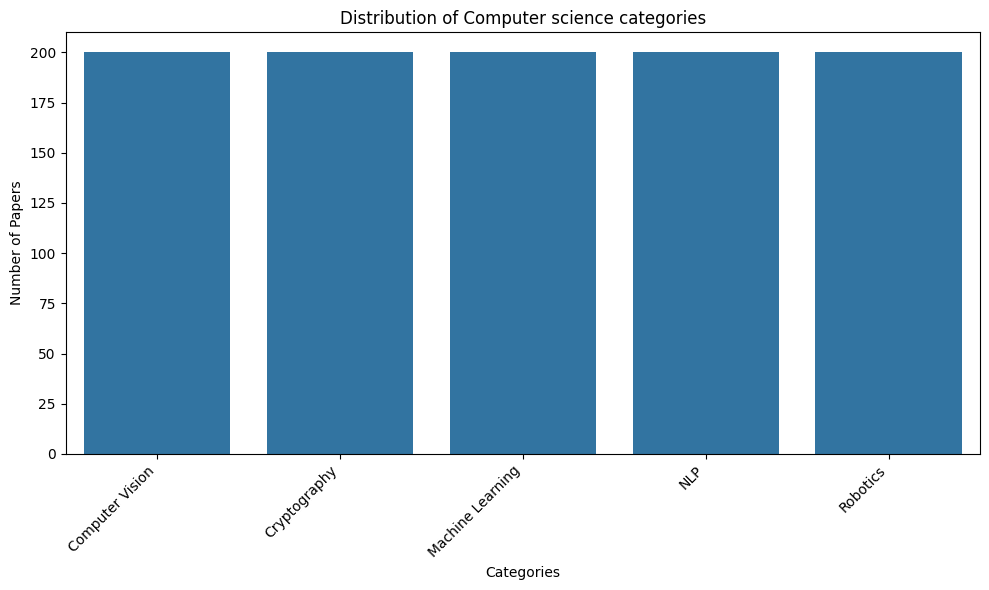

In [230]:
import matplotlib.pyplot as plt
import seaborn as sns



# Gets the value counts of the 'category' column
category_counts = final_df['label'].value_counts()

# Creates a bar plot to visualize the distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=category_counts.index, y=category_counts.values)
plt.title('Distribution of Computer science categories')
plt.xlabel('Categories')
plt.ylabel('Number of Papers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [231]:
stats_table = (
    final_df
    .groupby("label")
    .agg(
        Documents=("text", "count"),
        avg_total_words=("total_word_count", "mean"),
        avg_title_words=("title_word_count", "mean"),      # ← new
        avg_abstract_words=("abstract_word_count", "mean"), # ← new
        min_words=("total_word_count", "min"),
        max_words=("total_word_count", "max")
    )
    .reset_index()
)
stats_table

,label,Documents,avg_total_words,avg_title_words,avg_abstract_words,min_words,max_words
0,Computer Vision,200,150.0,9.830,140.170,150,150
1,Cryptography,200,150.0,9.265,140.735,150,150
2,Machine Learning,200,150.0,9.430,140.570,150,150
3,NLP,200,150.0,9.150,140.850,150,150
4,Robotics,200,150.0,9.890,140.110,150,150
